# 04 Loan Recommendation & Repayment Schedule

Turns the ML models from notebook 03 into customer-facing decisions: who is eligible, how much they can borrow, at what rate/tenure, why, and a year-by-year breakdown of what they'll pay vs. what they'll still owe. Also scores the untouched `Unseen_Dataset.xlsx` holdout batch and exports a consolidated workbook for dashboarding.

## 1. Imports and Load Everything

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

pd.set_option('display.max_columns', None)

df = pd.read_csv("../data/processed/featured_dataset.csv")
clf = joblib.load('../models/risk_tier_classifier.joblib')
reg = joblib.load('../models/loan_amount_regressor.joblib')
FEATURE_COLS = joblib.load('../models/feature_columns.joblib')
encoders = joblib.load('../models/label_encoders.joblib')

TIER_RULES = pd.read_csv('../reports/dim_risk_tier.csv').set_index('RiskTierID')
print("Loaded", df.shape, "rows;", len(FEATURE_COLS), "features")
TIER_RULES

Loaded (51336, 79) rows; 68 features


,Risk_Category,Eligibility_Status,Max_Loan_Amount,Interest_Rate_Pct,Tenure_Years,Repayment_Method,Income_Multiplier,Risk_Score_Range
RiskTierID,,,,,,,,
P1,Best Risk,Approved,2500000,8.5,5,EMI Fixed Monthly,5.0,750+
P2,Good Risk,Approved,1500000,10.5,4,EMI Fixed Monthly,3.5,700-749
P3,Moderate Risk,Conditional,750000,13.5,3,EMI Step-Up,2.0,650-699
P4,High Risk,Rejected,200000,18.0,2,Secured/Collateral,0.5,<650


## 2. Score Every Customer

For the deliverable tables below we score the **entire** customer base with the trained model, the way a bank would run it in production. Model performance itself (accuracy, precision/recall) was already measured honestly on the untouched test set in notebook 03 — this step is about producing the business output, not re-measuring accuracy.

In [2]:
X_all = df[FEATURE_COLS]
df['Predicted_Flag'] = clf.predict(X_all)
df['Prediction_Match'] = (df['Predicted_Flag'] == df['Approved_Flag']).astype(int)
df['Is_Eligible'] = df['Predicted_Flag'].isin(['P1', 'P2', 'P3']).astype(int)

print(df['Predicted_Flag'].value_counts())
print("\nOverall agreement with historical Approved_Flag:", df['Prediction_Match'].mean())
print("Eligible customers:", df['Is_Eligible'].sum(), "/", len(df))

Predicted_Flag
P2    32199
P3     7606
P4     5883
P1     5648
Name: count, dtype: int64

Overall agreement with historical Approved_Flag: 0.9964936886395512
Eligible customers: 45453 / 51336


## 3. Recommended Loan Amount, Interest Rate, Tenure, Repayment Method

The regressor's raw prediction is bounded by two business safety caps: the predicted tier's **maximum loan**, and an **ideal-zone affordability limit** — the largest loan whose monthly EMI stays within **30% of net monthly income** (applied to every income level). Keeping the EMI under 30% means basic needs and monthly savings stay unaffected, so the recommendation is safe, not just repayable.

In [3]:
df['Regressor_Raw_Amount'] = reg.predict(X_all)

IDEAL_FOIR = 0.30  # ideal/safe zone: EMI under 30% of income for every income level

def max_foir(nmi=None):
    # flat 30% ideal zone for all incomes, so basic needs + savings stay unaffected
    return IDEAL_FOIR

def affordable_loan(nmi, annual_rate_pct, tenure_years):
    if nmi <= 0:
        return 0.0
    max_emi = max_foir(nmi) * nmi
    r = (annual_rate_pct / 100.0) / 12.0
    n = tenure_years * 12
    if r == 0:
        return max_emi * n
    annuity_factor = ((1 + r) ** n - 1) / (r * (1 + r) ** n)
    return max_emi * annuity_factor

def risk_adjustment(credit_health_score):
    # weaker credit health -> lower factor -> smaller loan (range 0.6 - 1.0)
    return float(np.clip(0.6 + 0.4 * (credit_health_score / 100.0), 0.6, 1.0))

def cap_amount(row):
    if row['Is_Eligible'] == 0:
        return 0
    rule = TIER_RULES.loc[row['Predicted_Flag']]
    # affordability uses the customer's actual (raw) income, scaled by a credit-risk
    # factor so payment history changes the amount while the EMI stays <= 30%
    risk = risk_adjustment(row['Credit_Health_Score'])
    affordable = affordable_loan(row['NETMONTHLYINCOME'], rule['Interest_Rate_Pct'], rule['Tenure_Years']) * risk
    capped = min(max(row['Regressor_Raw_Amount'], 0), rule['Max_Loan_Amount'], affordable)
    return round(capped, -2)

df['Recommended_Loan_Amount'] = df.apply(cap_amount, axis=1)

# Minimum viable loan: if affordability supports less than this, the applicant's
# stated income is too low for this product -> not eligible. Real lenders have a
# minimum ticket size / income floor rather than issuing a token loan.
MIN_VIABLE_LOAN = 50000
income_too_low = (df['Is_Eligible'] == 1) & (df['Recommended_Loan_Amount'] < MIN_VIABLE_LOAN)
df.loc[income_too_low, ['Is_Eligible', 'Recommended_Loan_Amount']] = 0
print(f"Reclassified {int(income_too_low.sum())} applicants as not eligible "
      f"(income too low for the Rs.{MIN_VIABLE_LOAN:,} minimum loan)")

tier_lookup = TIER_RULES[['Interest_Rate_Pct', 'Tenure_Years', 'Repayment_Method']]
df = df.merge(tier_lookup, left_on='Predicted_Flag', right_index=True, how='left')
df.loc[df['Is_Eligible'] == 0, ['Interest_Rate_Pct', 'Tenure_Years']] = 0

print(df[['PROSPECTID','Predicted_Flag','Is_Eligible','Recommended_Loan_Amount',
          'Interest_Rate_Pct','Tenure_Years','Repayment_Method']].sample(10, random_state=1))

Reclassified 419 applicants as not eligible (income too low for the Rs.50,000 minimum loan)
       PROSPECTID Predicted_Flag  Is_Eligible  Recommended_Loan_Amount  \
24169       24170             P1            1                 280900.0   
24315       24316             P1            1                 200500.0   
29941       29942             P1            1                 259800.0   
47708       47709             P2            1                 314100.0   
45023       45024             P4            0                      0.0   
11756       11757             P2            1                 270000.0   
13160       13161             P2            1                 331700.0   
47643       47644             P2            1                 286600.0   
35712       35713             P3            1                 106000.0   
37523       37524             P2            1                 238200.0   

       Interest_Rate_Pct  Tenure_Years    Repayment_Method  
24169                8.5        

## 4. Monthly EMI

In [4]:
# Standard bank EMI formula -- given the loan, the interest rate and the number of
# years, it returns the fixed monthly instalment the customer will pay.
def compute_emi(principal, annual_rate_pct, tenure_years):
    if tenure_years <= 0 or principal <= 0:
        return 0.0
    r = (annual_rate_pct / 100.0) / 12.0   # monthly interest rate
    n = tenure_years * 12                   # total number of instalments
    if r == 0:
        return principal / n
    return principal * r * (1 + r) ** n / ((1 + r) ** n - 1)

# work out the EMI, total repayment and total interest for every eligible customer
df['Monthly_EMI'] = df.apply(
    lambda row: round(compute_emi(row['Recommended_Loan_Amount'], row['Interest_Rate_Pct'], row['Tenure_Years'])),
    axis=1
)
df['Total_Amount_Payable'] = df['Monthly_EMI'] * df['Tenure_Years'] * 12
df['Total_Interest_Payable'] = (df['Total_Amount_Payable'] - df['Recommended_Loan_Amount']).clip(lower=0)
df.loc[df['Is_Eligible'] == 0, ['Total_Amount_Payable', 'Total_Interest_Payable']] = 0

df[['PROSPECTID','Recommended_Loan_Amount','Monthly_EMI','Total_Interest_Payable','Total_Amount_Payable']].describe()

,PROSPECTID,Recommended_Loan_Amount,Monthly_EMI,Total_Interest_Payable,Total_Amount_Payable
count,51336.000000,5.133600e+04,51336.000000,51336.000000,5.133600e+04
mean,25668.500000,2.162227e+05,5557.320808,49393.556413,2.656162e+05
std,14819.571046,1.508281e+05,3673.912563,34651.359151,1.854752e+05
min,1.000000,0.000000e+00,0.000000,0.000000,0.000000e+00
25%,12834.750000,1.346000e+05,3620.000000,30576.000000,1.651680e+05
50%,25668.500000,1.925000e+05,5046.000000,43964.000000,2.364480e+05
75%,38502.250000,2.836000e+05,7259.000000,64888.000000,3.484320e+05
max,51336.000000,1.431300e+06,31231.000000,330600.000000,1.761900e+06


## 5. Reason for Approval / Rejection

In [5]:
def reason_for_decision(row):
    tier = row['Predicted_Flag']
    reasons = []
    if tier in ('P1', 'P2', 'P3'):
        if row['Tot_Missed_Pmnt'] == 0:
            reasons.append('No missed payments')
        if row['num_times_delinquent'] == 0:
            reasons.append('No delinquency history')
        if row['NETMONTHLYINCOME_Capped'] >= 30000:
            reasons.append(f"Stable income Rs.{row['NETMONTHLYINCOME_Capped']:,.0f}/mo")
        if row['Age_Oldest_TL'] >= 60:
            reasons.append(f"Mature credit ({row['Age_Oldest_TL']:.1f} months)")
        if row['enq_L3m'] == 0:
            reasons.append('No recent credit enquiries')
        if not reasons:
            reasons.append(f"Acceptable overall credit profile (score {row['Credit_Score']})")
    else:
        if row['Tot_Missed_Pmnt'] > 0:
            reasons.append(f"{int(row['Tot_Missed_Pmnt'])} missed payment(s) on record")
        if row['num_times_delinquent'] > 0:
            reasons.append('Delinquency history recorded')
        if row['Age_Oldest_TL'] < 24:
            reasons.append(f"Limited credit history ({row['Age_Oldest_TL']:.1f} months)")
        if row['enq_L3m'] >= 3:
            reasons.append(f"High recent enquiry volume ({int(row['enq_L3m'])} in last 3 months)")
        if not reasons:
            reasons.append(f"Low credit score ({row['Credit_Score']})")
    return '; '.join(reasons)

df['Reason_For_Decision'] = df.apply(reason_for_decision, axis=1)
# override reason for those filtered out purely on income affordability
df.loc[income_too_low, 'Reason_For_Decision'] = 'Stated net monthly income too low to service the minimum viable loan'
df[['PROSPECTID','Predicted_Flag','Reason_For_Decision']].sample(10, random_state=2)

,PROSPECTID,Predicted_Flag,Reason_For_Decision
35843,35844,P2,No missed payments; No delinquency history; St...
28001,28002,P2,No missed payments; No recent credit enquiries
41365,41366,P1,No missed payments; Mature credit (115.0 months)
5140,5141,P2,No delinquency history
10675,10676,P2,No delinquency history; No recent credit enqui...
12555,12556,P2,Stated net monthly income too low to service t...
19957,19958,P2,No missed payments; No delinquency history; St...
3536,3537,P2,Stated net monthly income too low to service t...
45983,45984,P2,No missed payments; No delinquency history; No...
35472,35473,P2,"No missed payments; Stable income Rs.45,700/mo..."


## 6. Year-by-Year Repayment Schedule

Vectorized across all eligible loans simultaneously (month-by-month, aggregated to years) — for each loan: how much principal and interest was paid that year, and the outstanding balance remaining at year end.

In [6]:
def vectorized_annual_schedule(ids, tier_ids, principal, annual_rate_pct, tenure_years):
    principal = np.asarray(principal, dtype=float)
    annual_rate_pct = np.asarray(annual_rate_pct, dtype=float)
    tenure_years = np.asarray(tenure_years, dtype=int)
    n = len(principal)

    r = (annual_rate_pct / 100.0) / 12.0
    tenure_months = tenure_years * 12
    with np.errstate(divide='ignore', invalid='ignore'):
        emi = np.where(
            r > 0,
            principal * r * (1 + r) ** tenure_months / ((1 + r) ** tenure_months - 1),
            principal / np.maximum(tenure_months, 1),
        )

    balance = principal.copy()
    max_months = int(tenure_months.max())
    year_principal = np.zeros(n)
    year_interest = np.zeros(n)
    records = []

    for month in range(1, max_months + 1):
        active = month <= tenure_months
        interest = np.where(active, balance * r, 0.0)
        principal_component = np.where(active, emi - interest, 0.0)
        principal_component = np.minimum(principal_component, balance)
        balance = np.where(active, balance - principal_component, balance)
        year_principal += principal_component
        year_interest += interest

        if month % 12 == 0:
            year_num = month // 12
            mask = year_num <= tenure_years
            records.append(pd.DataFrame({
                'CustomerID': ids[mask],
                'RiskTierID': tier_ids[mask],
                'LoanAmount': np.round(principal[mask]),
                'InterestRate_Pct': annual_rate_pct[mask],
                'Year': year_num,
                'EMI_Per_Month': np.round(emi[mask]),
                'Principal_Paid': np.round(year_principal[mask]),
                'Interest_Paid': np.round(year_interest[mask]),
                'Total_Paid_Year': np.round((year_principal + year_interest)[mask]),
                'Outstanding_Balance': np.round(np.maximum(balance[mask], 0)),
            }))
            year_principal[:] = 0.0
            year_interest[:] = 0.0

    return pd.concat(records, ignore_index=True)

eligible = df[df['Is_Eligible'] == 1].reset_index(drop=True)
fact_repayment = vectorized_annual_schedule(
    eligible['PROSPECTID'].values,
    eligible['Predicted_Flag'].values,
    eligible['Recommended_Loan_Amount'].values,
    eligible['Interest_Rate_Pct'].values,
    eligible['Tenure_Years'].values,
)
fact_repayment.insert(0, 'RepaymentID', np.arange(1, len(fact_repayment) + 1))
print("Repayment schedule rows:", len(fact_repayment))
fact_repayment.head(10)

Repayment schedule rows: 178215


,RepaymentID,CustomerID,RiskTierID,LoanAmount,InterestRate_Pct,Year,EMI_Per_Month,Principal_Paid,Interest_Paid,Total_Paid_Year,Outstanding_Balance
0,1,1,P2,491400.0,10.5,1,12582.0,104306.0,46672.0,150978.0,387094.0
1,2,2,P2,179900.0,10.5,1,4606.0,38186.0,17086.0,55273.0,141714.0
2,3,4,P2,84200.0,10.5,1,2156.0,17873.0,7997.0,25870.0,66327.0
3,4,5,P1,194400.0,8.5,1,3988.0,32587.0,15274.0,47861.0,161813.0
4,5,7,P1,345300.0,8.5,1,7084.0,57882.0,27130.0,85012.0,287418.0
5,6,8,P2,255500.0,10.5,1,6542.0,54233.0,24267.0,78500.0,201267.0
6,7,10,P1,220600.0,8.5,1,4526.0,36979.0,17332.0,54311.0,183621.0
7,8,11,P2,193300.0,10.5,1,4949.0,41030.0,18359.0,59390.0,152270.0
8,9,12,P2,292500.0,10.5,1,7489.0,62087.0,27781.0,89868.0,230413.0
9,10,13,P2,520800.0,10.5,1,13334.0,110547.0,49464.0,160011.0,410253.0


In [7]:
# Sanity check: final-year outstanding balance should be ~0, and principal paid
# across all years should sum back to the loan amount.
last_year = fact_repayment.sort_values(['CustomerID', 'Year']).groupby('CustomerID').tail(1)
print("Max final-year outstanding balance:", last_year['Outstanding_Balance'].abs().max())

totals = fact_repayment.groupby('CustomerID')['Principal_Paid'].sum()
loan_amounts = eligible.set_index('PROSPECTID')['Recommended_Loan_Amount']
diff = (totals - loan_amounts.loc[totals.index]).abs()
print("Max abs diff between summed principal paid and loan amount:", diff.max())

# spot check one customer
example_id = eligible['PROSPECTID'].iloc[0]
fact_repayment[fact_repayment['CustomerID'] == example_id]

Max final-year outstanding balance: 0.0
Max abs diff between summed principal paid and loan amount: 2.0


,RepaymentID,CustomerID,RiskTierID,LoanAmount,InterestRate_Pct,Year,EMI_Per_Month,Principal_Paid,Interest_Paid,Total_Paid_Year,Outstanding_Balance
0,1,1,P2,491400.0,10.5,1,12582.0,104306.0,46672.0,150978.0,387094.0
45034,45035,1,P2,491400.0,10.5,2,12582.0,115801.0,35177.0,150978.0,271293.0
90068,90069,1,P2,491400.0,10.5,3,12582.0,128563.0,22415.0,150978.0,142731.0
135102,135103,1,P2,491400.0,10.5,4,12582.0,142731.0,8247.0,150978.0,0.0


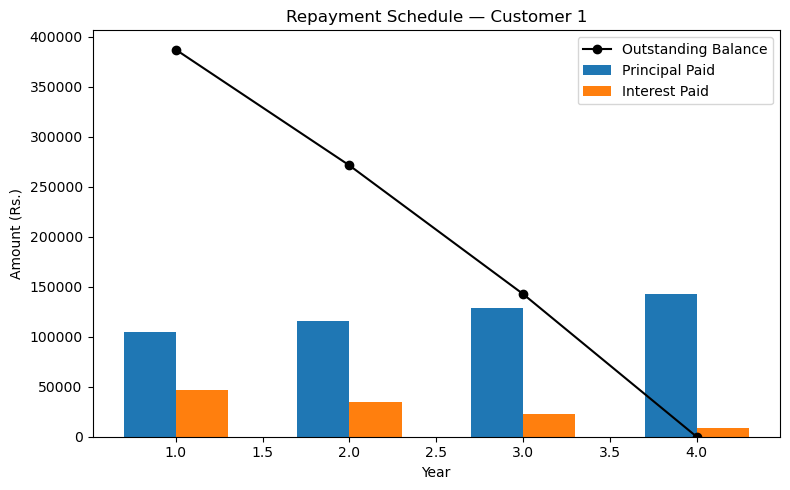

In [8]:
plt.figure(figsize=(8, 5))
example = fact_repayment[fact_repayment['CustomerID'] == example_id]
plt.bar(example['Year'] - 0.15, example['Principal_Paid'], width=0.3, label='Principal Paid')
plt.bar(example['Year'] + 0.15, example['Interest_Paid'], width=0.3, label='Interest Paid')
plt.plot(example['Year'], example['Outstanding_Balance'], color='black', marker='o', label='Outstanding Balance')
plt.xlabel('Year')
plt.ylabel('Amount (Rs.)')
plt.title(f'Repayment Schedule — Customer {example_id}')
plt.legend()
plt.tight_layout()
plt.savefig('../figures/example_repayment_schedule.png', dpi=120)
plt.show()

## 7. Score `Unseen_Dataset.xlsx`

This 100-row holdout batch is missing several fields our primary model needs — most notably `Credit_Score` itself — so we score it with the reduced-feature model trained in notebook 03 for exactly this scenario. Because `Credit_Health_Score` also can't be computed (it needs `Credit_Score`), the loan amount here uses the base tier rule (income x multiplier, capped) without the fine-grained risk adjustment applied to fully-featured customers.

In [9]:
unseen_df = pd.read_excel('../data/raw/Unseen_Dataset.xlsx')
reduced_clf = joblib.load('../models/risk_tier_classifier_reduced.joblib')
reduced_feature_cols = joblib.load('../models/reduced_feature_columns.joblib')

CAT_ENC_MAP = {'MARITALSTATUS_enc': 'MARITALSTATUS', 'EDUCATION_enc': 'EDUCATION',
               'GENDER_enc': 'GENDER', 'last_prod_enq2_enc': 'last_prod_enq2',
               'first_prod_enq2_enc': 'first_prod_enq2'}

for enc_col, raw_col in CAT_ENC_MAP.items():
    if raw_col in unseen_df.columns:
        le = encoders[raw_col]
        known = set(le.classes_)
        safe_vals = unseen_df[raw_col].astype(str).where(unseen_df[raw_col].astype(str).isin(known), le.classes_[0])
        unseen_df[enc_col] = le.transform(safe_vals)

num_cols_check = unseen_df.select_dtypes(include=[np.number]).columns.tolist()
unseen_df[num_cols_check] = unseen_df[num_cols_check].replace(-99999, np.nan)
for c in reduced_feature_cols:
    if unseen_df[c].isnull().any():
        unseen_df[c] = unseen_df[c].fillna(df[c].median() if c in df.columns else unseen_df[c].median())

unseen_df['ApplicationID'] = np.arange(1, len(unseen_df) + 1)
unseen_df['Predicted_Flag'] = reduced_clf.predict(unseen_df[reduced_feature_cols])
unseen_df['Is_Eligible'] = unseen_df['Predicted_Flag'].isin(['P1', 'P2', 'P3']).astype(int)

low, high = df['NETMONTHLYINCOME'].quantile([0.01, 0.99])
unseen_df['NETMONTHLYINCOME_Capped'] = unseen_df['NETMONTHLYINCOME'].clip(lower=low, upper=high)

def unseen_amount(row):
    if row['Is_Eligible'] == 0:
        return 0
    rule = TIER_RULES.loc[row['Predicted_Flag']]
    annual_income = row['NETMONTHLYINCOME_Capped'] * 12
    return round(min(annual_income * rule['Income_Multiplier'], rule['Max_Loan_Amount']), -2)

unseen_df['Recommended_Loan_Amount'] = unseen_df.apply(unseen_amount, axis=1)
unseen_df = unseen_df.merge(tier_lookup, left_on='Predicted_Flag', right_index=True, how='left')
unseen_df.loc[unseen_df['Is_Eligible'] == 0, ['Interest_Rate_Pct', 'Tenure_Years', 'Recommended_Loan_Amount']] = 0

print(unseen_df['Predicted_Flag'].value_counts())
unseen_df[['ApplicationID','Predicted_Flag','Is_Eligible','NETMONTHLYINCOME',
           'Recommended_Loan_Amount','Interest_Rate_Pct','Tenure_Years']].head(10)

Predicted_Flag
P2    77
P4    12
P3     6
P1     5
Name: count, dtype: int64


,ApplicationID,Predicted_Flag,Is_Eligible,NETMONTHLYINCOME,Recommended_Loan_Amount,Interest_Rate_Pct,Tenure_Years
0,1,P2,1,51000,1500000.0,10.5,4
1,2,P2,1,19000,798000.0,10.5,4
2,3,P2,1,18,336000.0,10.5,4
3,4,P1,1,15000,900000.0,8.5,5
4,5,P2,1,0,336000.0,10.5,4
5,6,P2,1,27000,1134000.0,10.5,4
6,7,P2,1,18000,756000.0,10.5,4
7,8,P2,1,20000,840000.0,10.5,4
8,9,P4,0,55000,0.0,0.0,0
9,10,P2,1,25000,1050000.0,10.5,4


## 8. Eligible Customers List (for Outreach)

Note: the source bureau/bank data has no contact-detail column (no phone or email), so the identifier here is `PROSPECTID` only — outreach would need to join this back to the bank's own customer contact system.

In [10]:
eligible_customers = df[df['Is_Eligible'] == 1][[
    'PROSPECTID', 'Predicted_Flag', 'Credit_Score', 'NETMONTHLYINCOME',
    'Recommended_Loan_Amount', 'Interest_Rate_Pct', 'Tenure_Years',
    'Repayment_Method', 'Monthly_EMI', 'Reason_For_Decision'
]].sort_values('Recommended_Loan_Amount', ascending=False).reset_index(drop=True)

os.makedirs('../reports', exist_ok=True)
eligible_customers.to_csv('../reports/eligible_customers.csv', index=False)
print(f"{len(eligible_customers):,} eligible customers written to ../reports/eligible_customers.csv")
eligible_customers.head(10)

45,034 eligible customers written to ../reports/eligible_customers.csv


,PROSPECTID,Predicted_Flag,Credit_Score,NETMONTHLYINCOME,Recommended_Loan_Amount,Interest_Rate_Pct,Tenure_Years,Repayment_Method,Monthly_EMI,Reason_For_Decision
0,32442,P1,736,350000,1431300.0,8.5,5,EMI Fixed Monthly,29365,"No delinquency history; Stable income Rs.78,00..."
1,22453,P1,704,200000,1412700.0,8.5,5,EMI Fixed Monthly,28984,"No delinquency history; Stable income Rs.78,00..."
2,28926,P1,728,200000,1377600.0,8.5,5,EMI Fixed Monthly,28264,"No delinquency history; Stable income Rs.78,00..."
3,46655,P1,705,380000,1372600.0,8.5,5,EMI Fixed Monthly,28161,"No delinquency history; Stable income Rs.78,00..."
4,38129,P1,730,500000,1343600.0,8.5,5,EMI Fixed Monthly,27566,"Stable income Rs.78,000/mo; Mature credit (199..."
5,36870,P1,706,171654,1319800.0,8.5,5,EMI Fixed Monthly,27078,No missed payments; No delinquency history; St...
6,24156,P1,735,135000,1303700.0,8.5,5,EMI Fixed Monthly,26747,"No missed payments; Stable income Rs.78,000/mo..."
7,26952,P1,707,100000,1271700.0,8.5,5,EMI Fixed Monthly,26091,No missed payments; No delinquency history; St...
8,11722,P1,727,100000,1269200.0,8.5,5,EMI Fixed Monthly,26040,"No delinquency history; Stable income Rs.78,00..."
9,41359,P1,754,150000,1267900.0,8.5,5,EMI Fixed Monthly,26013,No missed payments; No delinquency history; St...


## 9. Consolidated Excel Workbook

A single multi-sheet workbook for dashboarding, mirroring a standard fact/dimension layout.

In [11]:
fact_all_applications = df[[
    'PROSPECTID', 'Approved_Flag', 'Predicted_Flag', 'Credit_Score', 'NETMONTHLYINCOME',
    'Predicted_Flag', 'Credit_Score_Band', 'Is_Eligible', 'Prediction_Match'
]].copy()
fact_all_applications.columns = [
    'CustomerID', 'Actual_Flag', 'Predicted_Flag', 'Credit_Score', 'Net_Monthly_Income',
    'RiskTierID', 'Credit_Score_Band', 'Is_Eligible', 'Prediction_Match'
]

fact_loan_application = df[df['Is_Eligible'] == 1][[
    'PROSPECTID', 'Predicted_Flag', 'Recommended_Loan_Amount', 'Interest_Rate_Pct',
    'Tenure_Years', 'Repayment_Method', 'Monthly_EMI', 'Total_Interest_Payable',
    'Total_Amount_Payable', 'Credit_Health_Score', 'Income_TL_Ratio', 'Reason_For_Decision'
]].copy()
fact_loan_application.columns = [
    'CustomerID', 'RiskTierID', 'Recommended_Loan_Amount', 'Interest_Rate_Pct',
    'Tenure_Years', 'Repayment_Method', 'Monthly_EMI', 'Total_Interest_Payable',
    'Total_Amount_Payable', 'Credit_Health_Score', 'Income_TL_Ratio', 'Reason_For_Approval'
]

dim_customer = df[[
    'PROSPECTID', 'AGE', 'Age_Group', 'GENDER', 'MARITALSTATUS', 'EDUCATION',
    'NETMONTHLYINCOME', 'Income_Segment', 'Time_With_Curr_Empr'
]].copy()
dim_customer.insert(1, 'CustomerID_Ref', dim_customer['PROSPECTID'])
dim_customer['Annual_Income'] = dim_customer['NETMONTHLYINCOME'] * 12
dim_customer = dim_customer.drop(columns=['CustomerID_Ref']).rename(columns={'PROSPECTID': 'CustomerID', 'AGE': 'Age'})

credit_profile_cols = [c for c in [
    'PROSPECTID', 'Credit_Score', 'Credit_Health_Score', 'Income_TL_Ratio', 'Total_TL',
    'Tot_Active_TL', 'Tot_Missed_Pmnt', 'num_times_delinquent', 'Home_TL', 'PL_TL', 'CC_TL',
    'Gold_TL', 'Auto_TL', 'Consumer_TL', 'Unsecured_TL', 'Other_TL', 'Age_Oldest_TL',
    'Age_Newest_TL', 'time_since_recent_payment', 'enq_L12m', 'enq_L3m', 'CC_Flag', 'PL_Flag',
    'HL_Flag', 'GL_Flag', 'last_prod_enq2', 'first_prod_enq2', 'num_times_30p_dpd',
    'Credit_Score_Band'
] if c in df.columns]
dim_credit_profile = df[credit_profile_cols].copy().rename(columns={'PROSPECTID': 'CustomerID'})
dim_credit_profile['Has_Missed_Payment'] = (df['Tot_Missed_Pmnt'] > 0).astype(int)
dim_credit_profile['Has_Delinquency'] = (df['num_times_delinquent'] > 0).astype(int)

dim_risk_tier = TIER_RULES.reset_index()
dim_feature_importance = pd.read_csv('../reports/feature_importance.csv')
dim_model_performance = pd.read_csv('../reports/model_performance.csv')

fact_unseen_scoring = unseen_df[[
    'ApplicationID', 'Predicted_Flag', 'Is_Eligible', 'NETMONTHLYINCOME',
    'Recommended_Loan_Amount', 'Interest_Rate_Pct', 'Tenure_Years'
]].copy()

output_path = '../data/processed/Bank_Loan_Prediction_Results.xlsx'
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    fact_all_applications.to_excel(writer, sheet_name='fact_AllApplications', index=False)
    fact_loan_application.to_excel(writer, sheet_name='fact_LoanApplication', index=False)
    fact_repayment.to_excel(writer, sheet_name='fact_RepaymentSchedule', index=False)
    fact_unseen_scoring.to_excel(writer, sheet_name='fact_UnseenScoring', index=False)
    dim_customer.to_excel(writer, sheet_name='dim_Customer', index=False)
    dim_credit_profile.to_excel(writer, sheet_name='dim_CreditProfile', index=False)
    dim_risk_tier.to_excel(writer, sheet_name='dim_RiskTier', index=False)
    dim_feature_importance.to_excel(writer, sheet_name='dim_FeatureImportance', index=False)
    dim_model_performance.to_excel(writer, sheet_name='dim_ModelPerformance', index=False)

print("Saved consolidated workbook to", output_path)
for sheet, frame in [
    ('fact_AllApplications', fact_all_applications), ('fact_LoanApplication', fact_loan_application),
    ('fact_RepaymentSchedule', fact_repayment), ('fact_UnseenScoring', fact_unseen_scoring),
    ('dim_Customer', dim_customer), ('dim_CreditProfile', dim_credit_profile),
    ('dim_RiskTier', dim_risk_tier), ('dim_FeatureImportance', dim_feature_importance),
    ('dim_ModelPerformance', dim_model_performance),
]:
    print(f"  {sheet}: {frame.shape}")

Saved consolidated workbook to ../data/processed/Bank_Loan_Prediction_Results.xlsx
  fact_AllApplications: (51336, 9)
  fact_LoanApplication: (45034, 12)
  fact_RepaymentSchedule: (178215, 11)
  fact_UnseenScoring: (100, 7)
  dim_Customer: (51336, 10)
  dim_CreditProfile: (51336, 31)
  dim_RiskTier: (4, 9)
  dim_FeatureImportance: (68, 4)
  dim_ModelPerformance: (12, 2)


## 10. Save Processed Fact Tables (CSV)

In [12]:
fact_loan_application.to_csv('../data/processed/fact_LoanApplication.csv', index=False)
fact_repayment.to_csv('../data/processed/fact_RepaymentSchedule.csv', index=False)
print("Saved fact_LoanApplication.csv and fact_RepaymentSchedule.csv")

Saved fact_LoanApplication.csv and fact_RepaymentSchedule.csv
